In [1]:
!pip install -q transformers datasets evaluate sacrebleu bert-score nltk sentencepiece


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import torch
import time
import math
import warnings
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from bert_score import score as bert_score_fn
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Load Data

In [3]:
def load_parallel(sa_path, en_path):
    sa = pd.read_csv(sa_path, encoding="utf-8", engine="python", quotechar='"')
    en = pd.read_csv(en_path, encoding="utf-8", engine="python", quotechar='"')
    sa_text_col = [c for c in sa.columns if "Sentence" in c][0]
    en_text_col = [c for c in en.columns if "Sentence" in c][0]
    merged = pd.merge(
        sa[['Source_id', sa_text_col]], en[['Source_id', en_text_col]],
        on='Source_id', how='inner'
    ).sort_values('Source_id').reset_index(drop=True)
    merged.columns = ['Source_id', 'sanskrit', 'english']
    merged['sanskrit'] = merged['sanskrit'].astype(str).str.strip()
    merged['english'] = merged['english'].astype(str).str.strip()
    merged = merged[(merged['sanskrit'] != '') & (merged['english'] != '')].reset_index(drop=True)
    return merged

train_df = load_parallel("train_sa_10000.csv", "train_en_10000.csv")
dev_df = load_parallel("dev_sa_1000.csv", "dev_en_1000.csv")
test_df = load_parallel("test_demo_sa - Sheet1 - test_demo_sa - Sheet1.csv", "test_demo_en - Sheet1 - test_demo_en - Sheet1.csv")

print(f"Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")

Train: 10000 | Dev: 1000 | Test: 100


In [4]:
MODEL_PATH = "./final_mbart_lora_v2"
BASE_MODEL = "facebook/mbart-large-50-many-to-many-mmt"

# Load tokenizer from HuggingFace hub (not saved model)
# because saved tokenizer has src_lang=sa_IN which is not in mBART-50's language list
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.src_lang = "hi_IN"  # Hindi — same Devanagari script as Sanskrit
tokenizer.tgt_lang = "en_XX"

# Get English BOS token ID for generation
EN_BOS_ID = tokenizer.convert_tokens_to_ids("en_XX")
print(f"English BOS token ID: {EN_BOS_ID}")

# Load fine-tuned model weights from best checkpoint
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded from {MODEL_PATH}")
print(f"Total parameters: {total_params:,}")

English BOS token ID: 250004


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

✅ Model loaded from ./final_mbart_lora_v2
Total parameters: 615,598,080


## Translate Test Set

In [5]:
def translate_batch(sentences, max_length=128, num_beams=5, length_penalty=1.1):
    inputs = tokenizer(
        sentences, return_tensors="pt", padding=True,
        truncation=True, max_length=max_length
    ).to(device)
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            forced_bos_token_id=EN_BOS_ID,
            num_beams=num_beams,
            length_penalty=length_penalty,
            max_length=max_length,
            early_stopping=True
        )
    return tokenizer.batch_decode(generated, skip_special_tokens=True)

def translate_all(sentences, batch_size=8):
    all_translations = []
    total = math.ceil(len(sentences) / batch_size)
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        all_translations.extend(translate_batch(batch))
        b = i // batch_size + 1
        if b % 10 == 0 or b == total:
            print(f"  {b}/{total}")
    return all_translations

# Quick test
print(f"SA:   {test_df['sanskrit'].iloc[0]}")
print(f"Pred: {translate_batch([test_df['sanskrit'].iloc[0]])[0]}")
print(f"Ref:  {test_df['english'].iloc[0]}")

SA:   हे भ्रातरो युष्माकम् आत्माभिमानो यन्न जायते तदर्थं ममेदृशी वाञ्छा भवति यूयं एतन्निगूढतत्त्वम् अजानन्तो यन्न तिष्ठथ; वस्तुतो यावत्कालं सम्पूर्णरूपेण भिन्नदेशिनां संग्रहो न भविष्यति तावत्कालम् अंशत्वेन इस्रायेलीयलोकानाम् अन्धता स्थास्यति;
Pred: "Woe unto you, brethren! for your souls are in darkness, and ye are blind as I am: for there is no whole collection of things, neither is there any part of the children of Israel."
Ref:  "For I would not, brethren, that ye should be ignorant of this mystery, lest ye should be wise in your own conceits; that blindness in part is happened to Israel, until the fulness of the Gentiles be come in."


In [6]:
test_sentences = test_df['sanskrit'].tolist()
reference_sentences = test_df['english'].tolist()

# Warm-up
_ = translate_batch(test_sentences[:4])

# Timed inference
if torch.cuda.is_available(): torch.cuda.synchronize()
start_time = time.time()

predicted_translations = translate_all(test_sentences, batch_size=8)

if torch.cuda.is_available(): torch.cuda.synchronize()
inference_time = time.time() - start_time

print(f"\n✅ {len(test_sentences)} sentences in {inference_time:.2f}s ({len(test_sentences)/inference_time:.1f} sent/s)")

  10/13
  13/13

✅ 100 sentences in 28.62s (3.5 sent/s)


## submission.csv

In [7]:
submission = pd.DataFrame({
    'Source_id': test_df['Source_id'].values,
    'Sentence_en': predicted_translations
})
submission.to_csv('submission.csv', index=False, encoding='utf-8')

print("✅ submission.csv saved!")
print(f"Shape: {submission.shape}")
submission.head()

✅ submission.csv saved!
Shape: (100, 2)


,Source_id,Sentence_en
0,1001,"""Woe unto you, brethren! for your souls are in..."
1,1002,The legs are stiff and the shape is right. The...
2,1003,"In this tutorial, we learnt about: admin role ..."
3,1004,"In our course page, you can see the menu chang..."
4,1005,These are available to students who wish to jo...


## BLEU Score (NLTK, no weights)

In [8]:
tokenized_preds = [word_tokenize(p.lower()) for p in predicted_translations]
tokenized_refs = [[word_tokenize(r.lower())] for r in reference_sentences]

bleu_score = corpus_bleu(tokenized_refs, tokenized_preds)
bleu_1 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(1, 0, 0, 0))
bleu_2 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.5, 0.5, 0, 0))
bleu_3 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.33, 0.33, 0.33, 0))
bleu_4 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.25, 0.25, 0.25, 0.25))

print(f"BLEU-1: {bleu_1:.4f}")
print(f"BLEU-2: {bleu_2:.4f}")
print(f"BLEU-3: {bleu_3:.4f}")
print(f"BLEU-4: {bleu_4:.4f}")
print(f"\nCorpus BLEU (default): {bleu_score:.4f}")

BLEU-1: 0.3884
BLEU-2: 0.2515
BLEU-3: 0.1758
BLEU-4: 0.1279

Corpus BLEU (default): 0.1279


## BERTScore (F1, rescale_with_baseline=True)

In [9]:
P, R, F1 = bert_score_fn(
    predicted_translations, reference_sentences,
    lang="en", rescale_with_baseline=True, verbose=True
)
bert_f1_avg = F1.mean().item()

print(f"\nBERTScore Precision: {P.mean().item():.4f}")
print(f"BERTScore Recall:    {R.mean().item():.4f}")
print(f"BERTScore F1:        {bert_f1_avg:.4f}")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 1.40 seconds, 71.39 sentences/sec

BERTScore Precision: 0.4344
BERTScore Recall:    0.3795
BERTScore F1:        0.4070


## Efficiency

In [10]:
print(f"Total Parameters:    {total_params:,}")
print(f"Inference Time:      {inference_time:.2f}s ({len(test_sentences)} sentences)")
print(f"Avg Time/Sentence:   {inference_time/len(test_sentences):.4f}s")
print(f"Throughput:          {len(test_sentences)/inference_time:.1f} sent/s")

Total Parameters:    615,598,080
Inference Time:      28.62s (100 sentences)
Avg Time/Sentence:   0.2862s
Throughput:          3.5 sent/s


## Dev Set Evaluation

In [12]:
dev_predictions = translate_all(dev_df['sanskrit'].tolist(), batch_size=8)
dev_references = dev_df['english'].tolist()

dev_bleu = corpus_bleu(
    [[word_tokenize(r.lower())] for r in dev_references],
    [word_tokenize(p.lower()) for p in dev_predictions]
)
_, _, dev_F1 = bert_score_fn(
    dev_predictions, dev_references,
    lang="en", rescale_with_baseline=True, verbose=False
)
print(f"Dev BLEU:      {dev_bleu:.4f}")
print(f"Dev BERTScore: {dev_F1.mean().item():.4f}")

  10/125
  20/125
  30/125
  40/125
  50/125
  60/125
  70/125
  80/125
  90/125
  100/125
  110/125
  120/125
  125/125


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dev BLEU:      0.1544
Dev BERTScore: 0.4346


## Training Curves

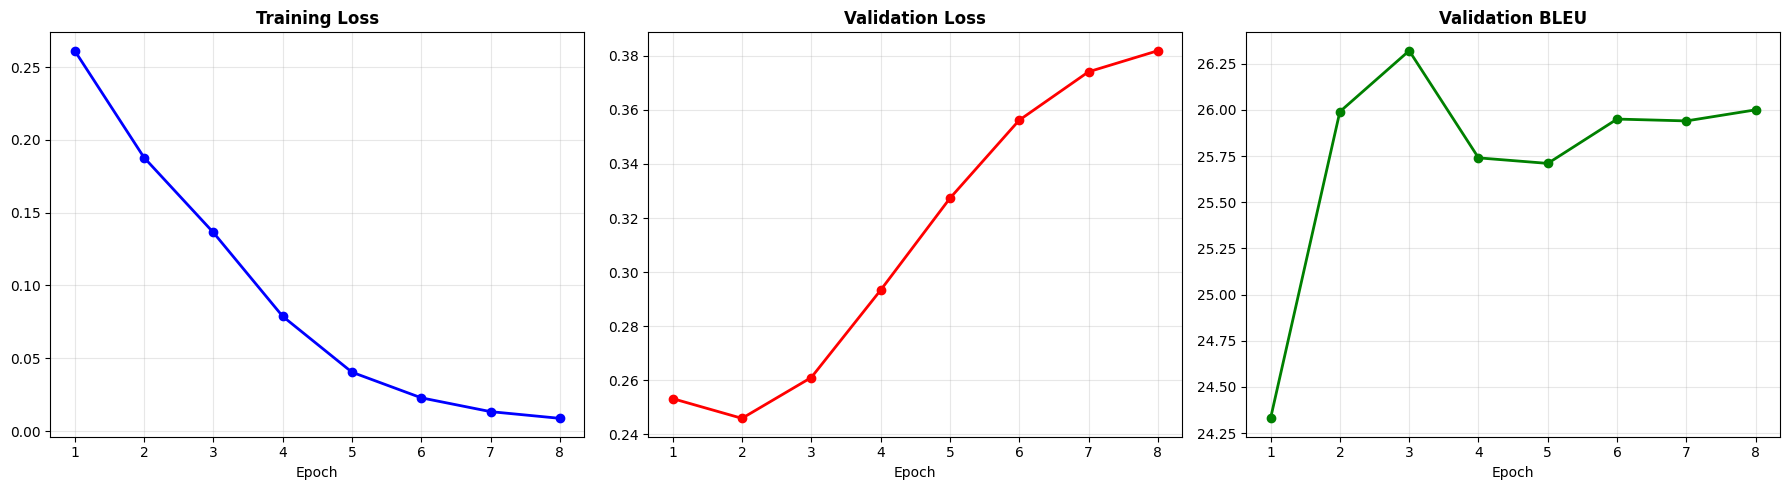

In [13]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8]
train_loss = [0.2613, 0.1879, 0.1364, 0.0788, 0.0404, 0.0228, 0.0133, 0.0087]
val_loss   = [0.2532, 0.2459, 0.2610, 0.2933, 0.3273, 0.3562, 0.3741, 0.3819]
val_bleu   = [24.33, 25.99, 26.32, 25.74, 25.71, 25.95, 25.94, 26.00]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(epochs, train_loss, 'b-o', lw=2); axes[0].set_title('Training Loss', fontweight='bold'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs, val_loss, 'r-o', lw=2); axes[1].set_title('Validation Loss', fontweight='bold'); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)
axes[2].plot(epochs, val_bleu, 'g-o', lw=2); axes[2].set_title('Validation BLEU', fontweight='bold'); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

## Translation Examples

In [14]:
per_bleu = np.array([sentence_bleu(r, p) if len(p) > 0 else 0.0 for p, r in zip(tokenized_preds, tokenized_refs)])
bert_scores = F1.numpy()

def show(idx, label):
    print(f"\n{label} | BLEU: {per_bleu[idx]:.4f} | BERTScore: {bert_scores[idx]:.4f}")
    print(f"  Source:  {test_df['sanskrit'].iloc[idx]}")
    print(f"  Ref:     {reference_sentences[idx]}")
    print(f"  Pred:    {predicted_translations[idx]}")
    missing = set(reference_sentences[idx].lower().split()) - set(predicted_translations[idx].lower().split())
    extra = set(predicted_translations[idx].lower().split()) - set(reference_sentences[idx].lower().split())
    if missing: print(f"  Missing: {', '.join(list(missing)[:6])}")
    if extra: print(f"  Extra:   {', '.join(list(extra)[:6])}")

print("=" * 70 + "\nTOP 5 BEST\n" + "=" * 70)
for i, idx in enumerate(np.argsort(per_bleu)[-5:][::-1], 1): show(idx, f"#{i}")

print("\n" + "=" * 70 + "\nTOP 5 WORST\n" + "=" * 70)
for i, idx in enumerate(np.argsort(per_bleu)[:5], 1): show(idx, f"#{i}")

TOP 5 BEST

#1 | BLEU: 1.0000 | BERTScore: 1.0000
  Source:  double slash “//” space “My first C++ program” इति टङ्कयन्तु ।
  Ref:     Type double slash “//” space “My first C++ program”.
  Pred:    Type double slash “//” space “My first C++ program”.

#2 | BLEU: 0.9193 | BERTScore: 0.8947
  Source:  एतदनुशिक्षणं रेकार्ड् कर्तुम् अहं : Ubuntu Linux Operating System 16.04
  Ref:     To record this tutorial, I am using  Ubuntu Linux Operating System 16.04
  Pred:    To record this tutorial, I am using Ubuntu Linux Operating System 16.04.
  Missing: 16.04
  Extra:   16.04.

#3 | BLEU: 0.7395 | BERTScore: 0.8002
  Source:  जानन्तु यत्,  Human क्लास् इतीदं,  talk(), see() अपि च  move() मेथड्स् इत्येतेषां स्वकीयम् इम्प्लिमेण्टेशन् प्राप्तवदस्ति ।
  Ref:     Note that the Human class has its own implementations of talk(), see() and move() methods.
  Pred:    But the Human class has its own elements like talk(), see() and move() methods.
  Missing: note, of, implementations, that
  Extra:   el

## Evaluation Plots

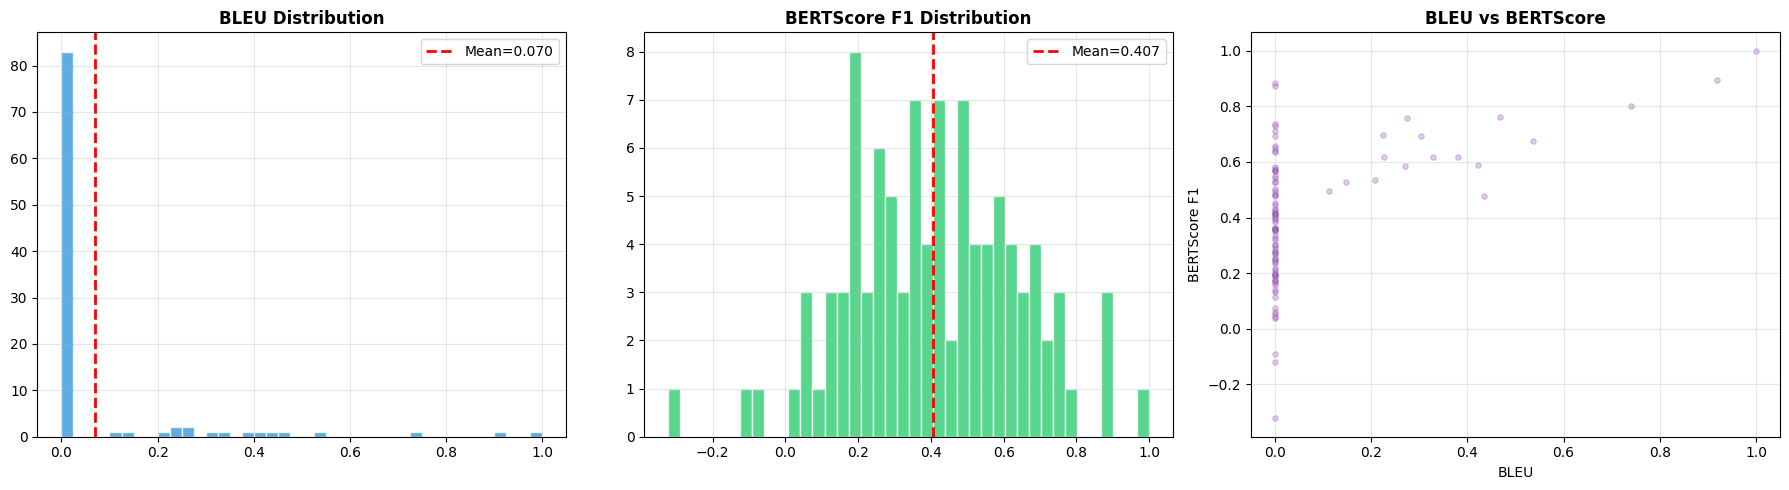

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(per_bleu, bins=40, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].axvline(per_bleu.mean(), color='red', lw=2, ls='--', label=f'Mean={per_bleu.mean():.3f}')
axes[0].set_title('BLEU Distribution', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(bert_scores, bins=40, color='#2ECC71', edgecolor='white', alpha=0.8)
axes[1].axvline(bert_f1_avg, color='red', lw=2, ls='--', label=f'Mean={bert_f1_avg:.3f}')
axes[1].set_title('BERTScore F1 Distribution', fontweight='bold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].scatter(per_bleu, bert_scores, alpha=0.3, s=15, color='#9B59B6')
axes[2].set_xlabel('BLEU'); axes[2].set_ylabel('BERTScore F1')
axes[2].set_title('BLEU vs BERTScore', fontweight='bold'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight'); plt.show()

## Final Summary

In [16]:
print("=" * 60)
print("  SANSKRIT → ENGLISH TRANSLATION RESULTS")
print("=" * 60)
print(f"  Model: mBART-50 (fine-tuned, best checkpoint)")
print(f"  Architecture: 12L Enc + 12L Dec, d=1024, 16 heads")
print(f"  Training: lr=3e-5, 8 epochs, batch=8, fp16")
print(f"")
print(f"  Test BLEU:      {bleu_score:.4f}")
print(f"  Test BERTScore: {bert_f1_avg:.4f}")
print(f"  Dev BLEU:       {dev_bleu:.4f}")
print(f"  Dev BERTScore:  {dev_F1.mean().item():.4f}")
print(f"")
print(f"  Parameters:     {total_params:,}")
print(f"  Inference Time: {inference_time:.2f}s")
print(f"  submission.csv: {submission.shape[0]} rows")
print("=" * 60)

  SANSKRIT → ENGLISH TRANSLATION RESULTS
  Model: mBART-50 (fine-tuned, best checkpoint)
  Architecture: 12L Enc + 12L Dec, d=1024, 16 heads
  Training: lr=3e-5, 8 epochs, batch=8, fp16

  Test BLEU:      0.1279
  Test BERTScore: 0.4070
  Dev BLEU:       0.1544
  Dev BERTScore:  0.4346

  Parameters:     615,598,080
  Inference Time: 28.62s
  submission.csv: 100 rows
